### Imports & Global Vars

In [7]:
import os
import pandas as pd
import torch

In [8]:
from LatentGateModel import LatentGateModel, Classifier
from TopoFeatExtractor import TopoFeatExtractor
from MeSHDataLoaders import load_ddi_data, create_folds
from FusionTrainer import FusionTrainer
from utils import compare_models, plot_performance_by_category_with_sig

In [9]:
# For reproducibility
torch.manual_seed(42)
pd.options.display.max_columns = None

In [10]:
# ⚙️ 2. Paths & Experiment Settings
graph_path = "networks/weighted_dppi_PubMedBERT.graphml"
pos_path = "datasets/DDI_positive_pairs.csv"
neg_path = "datasets/DDI_negative_pairs.csv"
emb_dir = "datasets/"
extended_drug_categories_path = "datasets/extended_drug_info.csv"

In [ ]:
# Experiment hyperparameters
n_splits   = 5
batch_size = 128
epochs     = 20
lr         = 1e-3
weight_decay = 1e-5
seed       = 42
patience   = 5
num_experiments = 2
use_betweenness = False # Whether to use betweenness centrality as a topo feature --> It takes too long :(

### Load Data

In [6]:
# Load MeSH-based embeddings + DDI pairs for 'mid_level'
X, y, pairs = load_ddi_data(
    level="mid_level",
    pos_path=pos_path,
    neg_path=neg_path,
    emb_dir=emb_dir,
    seed=seed,
)
folds = create_folds(X, y, n_splits=n_splits, seed=seed)


[mid_level] Drug coverage check:
   Positives covered: 453,524
   Negatives covered: 5,391
   ⚖️  Sampled 5,391 positives to match 5,391 negatives (Δ=0).
[mid_level] Final dataset: 10,782 pairs (5391 pos, 5391 neg)
→ Feature shape: (10782, 256)


In [7]:
# Load drug category mapping (low, mid, deep)
drug_to_cat = pd.read_csv(extended_drug_categories_path).set_index("drugbank_id")["knowledge_category"].to_dict()

In [8]:
# --- Load per-drug embeddings (for fusion model only) ---
emb_df = pd.read_csv(f"{emb_dir}/MeSH_mid_level_tfidf_svd128.csv", index_col=0)

### Init Models & FE

In [9]:
topo_feat_extractor = TopoFeatExtractor(graph_path, use_betweenness=use_betweenness)
num_topo_feats = topo_feat_extractor.num_of_topo_feats

Loading base graph from networks/weighted_dppi_PubMedBERT.graphml ...
Graph loaded: 17976 nodes, 268307 edges
Found 3263 drug nodes.



In [10]:
# init simple classifier - baseline for mesh
baseline_cls = Classifier(input_dim=256, hidden=(256, 128), dropout=0.1)

In [11]:
# init fusion model
fusion_model = LatentGateModel(
    bio_dim=128,
    topo_dim=num_topo_feats,
    latent_dim=128,
    fusion_mode="concat",
    enc_hidden=(256,),
    head_hidden=(256, 128),
    dropout=0.1,
    gate_scalar=False,
    gate_bias_init=0.7
)

### Trainer

In [12]:

fusion_trainer = FusionTrainer(    
    model_cls=fusion_model,
    baseline_cls=baseline_cls,
    topo_extractor=topo_feat_extractor,
    device="cuda" if torch.cuda.is_available() else "cpu",
    n_splits=n_splits,
    batch_size=batch_size,
    epochs=epochs,
    lr=lr,
    weight_decay=weight_decay,
    seed=seed,
    patience=patience,
    out_dir="results"
)

### Run Experiments

In [13]:
fusion_trainer.run_experiments(
    X=X,
    y=y,
    pairs=pairs,
    folds=folds,
    emb_df=emb_df,
    drug_to_cat=drug_to_cat,
    num_experiments=num_experiments
)


=== Experiment 1/2 ===

--- Fold 1/5 ---
Removing 1088 eval DDI edges for leakage safety.
→ Processed 500/1667 drugs (15.1s elapsed)
→ Processed 1000/1667 drugs (29.5s elapsed)
→ Processed 1500/1667 drugs (43.5s elapsed)
✅ Finished 1667 drugs in 48.4s total.
Computed features for 1667 drugs.
Early stop at epoch 6 (val loss = 0.2681)
Baseline evaluation: {'low_level-low_level': 0.951578947368421, 'low_level-mid_level': 0.9622307010444368, 'low_level-deep_level': 0.9841777777777778, 'mid_level-mid_level': 0.9693013448826078, 'mid_level-deep_level': 0.9530898560503824, 'deep_level-deep_level': 0.9606060606060607}
Epoch 001: train_loss=0.4185, val_loss=0.2879
Epoch 002: train_loss=0.2819, val_loss=0.2667
Epoch 003: train_loss=0.2383, val_loss=0.2545
Epoch 004: train_loss=0.2121, val_loss=0.2446
Epoch 005: train_loss=0.1936, val_loss=0.2224
Epoch 006: train_loss=0.1758, val_loss=0.3149
Early stop fusion at epoch 6 (val loss = 0.3149)
Fusion evaluation: {'low_level-low_level': 0.974, 'low_l

### Visualize with Stat Significance Test 

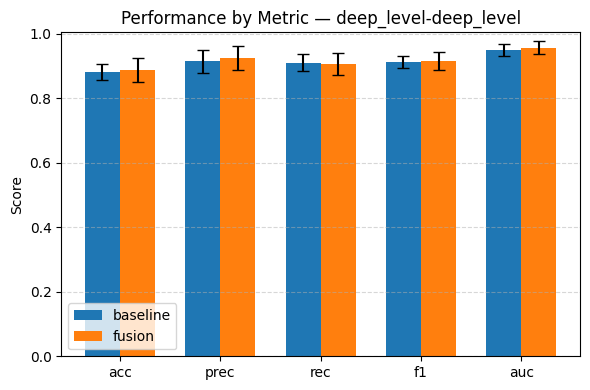

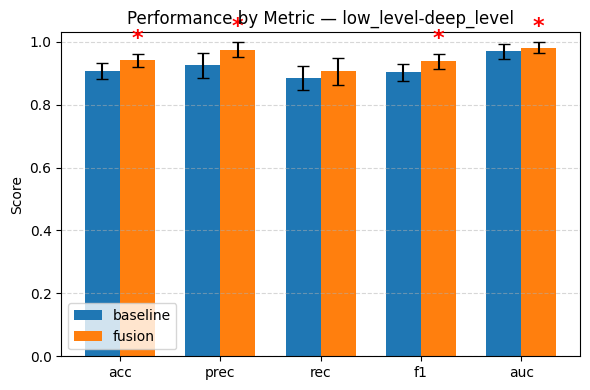

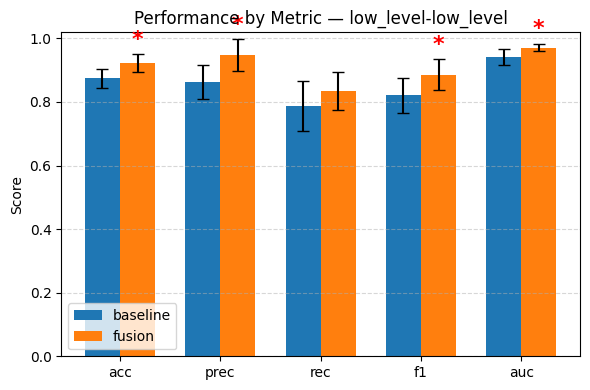

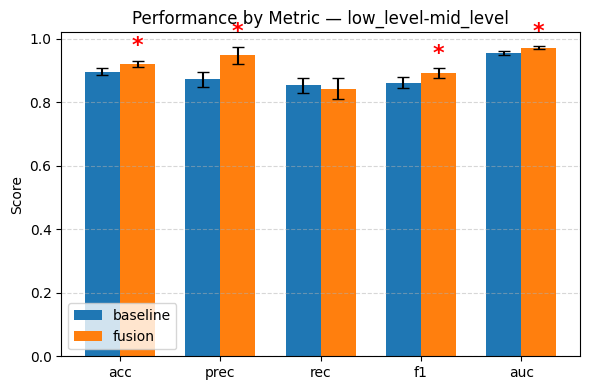

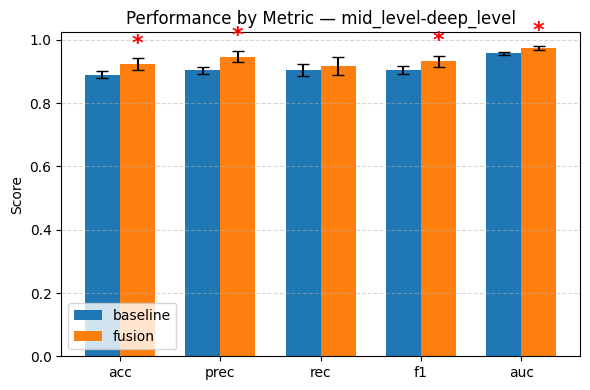

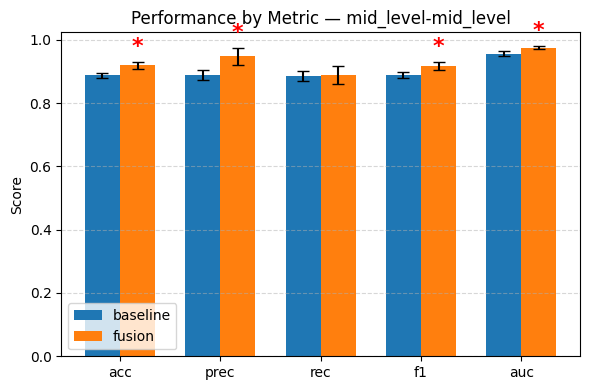

✅ Plots (mean ± std, significance) saved and shown for 6 categories → results/plots


In [20]:
plot_performance_by_category_with_sig(fusion_trainer.results_df, show=True)